### Learning Goal
- **What concept is this notebook teaching?** XGBoost & Gradient Boosting (IPL Final Score Prediction).
- **Why does it matter?** It teaches sequential ensemble regression, where each new tree learns to predict the residual runs left unexplained by the previous trees, via gradient descent.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/ball_by_ball_ipl.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())


   Unnamed: 0  Match ID        Date         Venue            Bat First  \
0           0   1359507  2023-04-23  Eden Gardens  Chennai Super Kings   
1           1   1359507  2023-04-23  Eden Gardens  Chennai Super Kings   
2           2   1359507  2023-04-23  Eden Gardens  Chennai Super Kings   
3           3   1359507  2023-04-23  Eden Gardens  Chennai Super Kings   
4           4   1359507  2023-04-23  Eden Gardens  Chennai Super Kings   

              Bat Second  Innings  Over  Ball      Batter  ...  \
0  Kolkata Knight Riders        1     1     1  RD Gaikwad  ...   
1  Kolkata Knight Riders        1     1     2  RD Gaikwad  ...   
2  Kolkata Knight Riders        1     1     3  RD Gaikwad  ...   
3  Kolkata Knight Riders        1     1     4  RD Gaikwad  ...   
4  Kolkata Knight Riders        1     1     5  RD Gaikwad  ...   

                Winner Chased Successfully  Total Batter Runs  \
0  Chennai Super Kings                   0                  4   
1  Chennai Super Kings      

In [2]:
print('\nDuplicates:')
print(df[df.duplicated(keep=False)].count().iloc[0] if not df[df.duplicated(keep=False)].empty else 0)
df.drop_duplicates(inplace=True)



Duplicates:
0


In [3]:

final_scores = df.groupby(['Match ID', 'Innings'])['Innings Runs'].max().reset_index()
final_scores.rename(columns={'Innings Runs': 'Final_Innings_Runs'}, inplace=True)
df = df.merge(final_scores, on=['Match ID', 'Innings'])

df = df[df['Innings'] == 1].copy()

features_to_keep = [
    'Venue', 'Bat First', 'Bat Second', 'Over', 'Ball', 
    'Innings Runs', 'Innings Wickets', 'Final_Innings_Runs'
]
df = df[features_to_keep].dropna()

df = df.sample(n=20000, random_state=42).reset_index(drop=True)


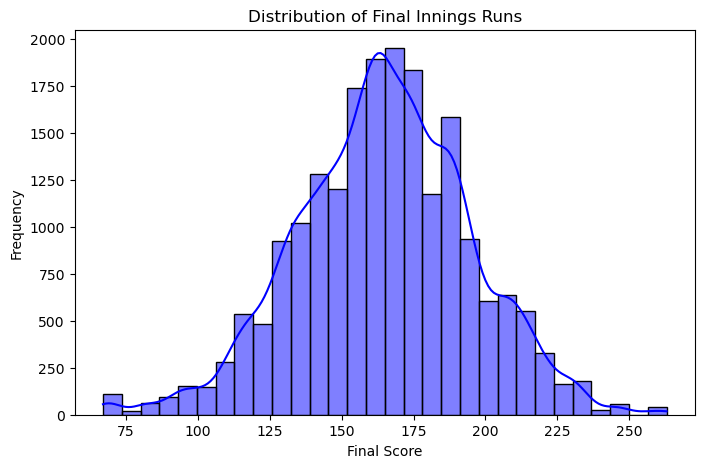

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Final_Innings_Runs'], bins=30, kde=True, color='blue')
plt.title('Distribution of Final Innings Runs')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.show()


### Visualization Analysis: Distribution Plot
- **Marking Values:** Note the peak (mode) of the distribution, the spread (variance), and any long tails stretching to the left or right.
- **Correct Interpretation:** A "bell curve" indicates normally distributed data. A long tail to the right indicates positive skew (e.g., wealth distribution), which linear models struggle with.
- **How to Interpret:** The height of the bars/curve represents the frequency or density of data points occurring at that specific X-value.
- **Common Mistakes:** Failing to apply a log-transform to highly skewed target variables before training a regression model.

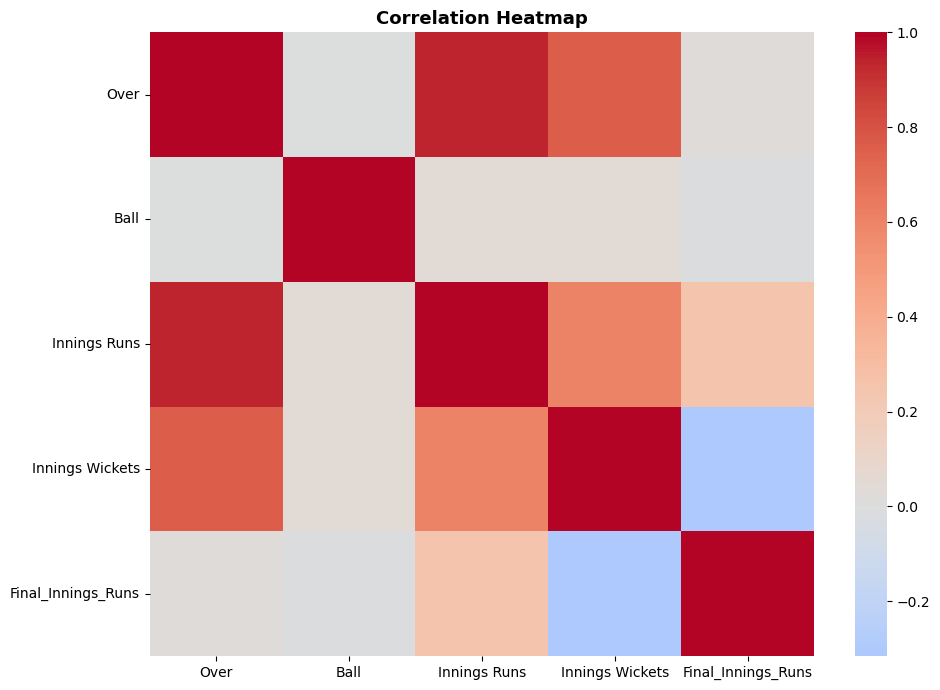

In [5]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [6]:
X = df.drop(columns=['Final_Innings_Runs'])
y = df['Final_Innings_Runs']

print(X.select_dtypes(include='number').skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42
)


Over              -0.002692
Ball              -0.012917
Innings Runs       0.372423
Innings Wickets    0.788151
dtype: float64


In [7]:
from sklearn.pipeline import Pipeline
# Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
random_forest_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Construct an ensemble of uncorrelated decision trees via bootstrap aggregating (bagging) to drastically reduce model variance.
    ('model', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
gradient_boost_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

# Encapsulate sequential data transformations and the final estimator to guarantee identical preprocessing during inference.
xgboost_model = Pipeline([
    # Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
    ('scaler', StandardScaler()),
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    ('model', XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])


### Experiment
- **What are we changing?** Comparing three ensemble regressors — Random Forest (parallel bagging), Gradient Boosting, and XGBoost (both sequential boosting) — on the same IPL first-innings features.
- **What do we expect to happen?** The boosting models should edge out Random Forest on R², since predicting a continuous, still-in-progress score benefits from sequentially correcting earlier residual errors.

In [8]:
from tqdm.auto import tqdm

models = {
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boost_model,
    # Initialize a Gradient Boosting ensemble that trains trees sequentially, with each new tree minimizing the residual errors of its predecessors.
    "XGBoost": xgboost_model,
}

for name, model in tqdm(models.items(), desc="Training Models"):
    model.fit(X_train, y_train)


Training Models:   0%|          | 0/3 [00:00<?, ?it/s]

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

evaluation_data = []

for name, model in models.items():
    preds = model.predict(X_test)
    
    # Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
    mae = mean_absolute_error(y_test, preds)
    # Heavily penalize massive prediction errors by squaring the residuals before averaging.
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    evaluation_data.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

metrics_table = (
    pd.DataFrame(evaluation_data)
      .set_index("Model")
      .round(4)
)

print(metrics_table)


                       MAE       MSE     RMSE  R2 Score
Model                                                  
Random Forest      16.4639  485.4384  22.0327    0.4630
Gradient Boosting  15.4299  421.9773  20.5421    0.5332
XGBoost            13.1447  320.9127  17.9140    0.6450


In [10]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    # Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_df = (
    pd.DataFrame(cv_results)
      .set_index("Model")
      .round(4)
)

print(cv_df)


                   Mean CV R2  Std CV R2
Model                                   
Random Forest          0.4814     0.0072
Gradient Boosting      0.5467     0.0111
XGBoost                0.6506     0.0111


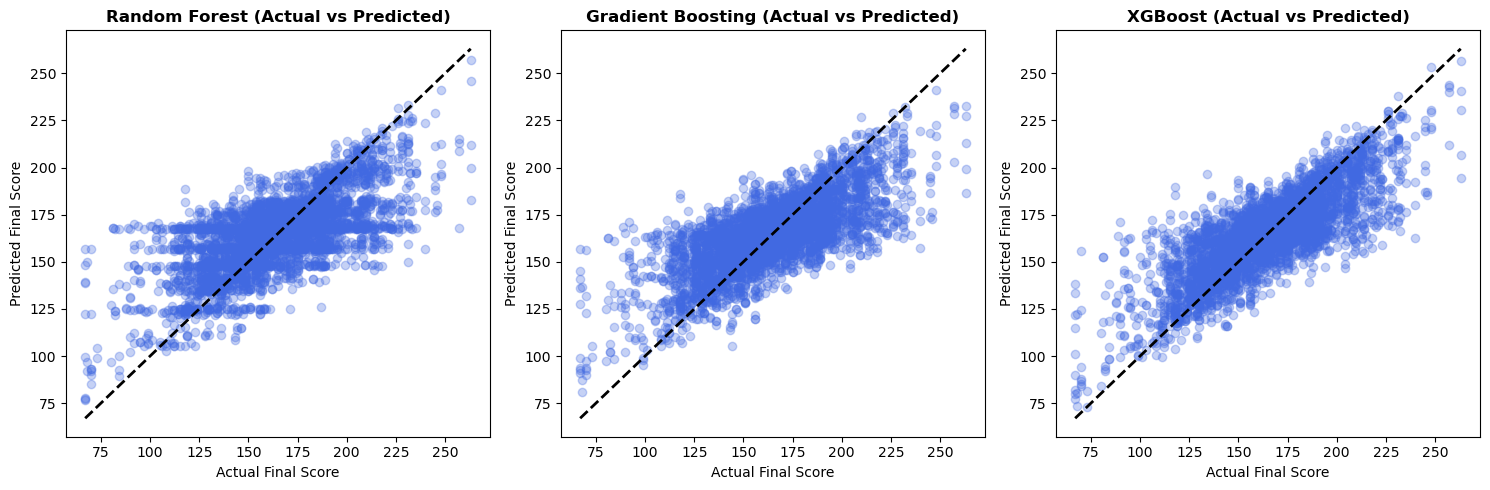

In [11]:
import math

cols = 3
rows = math.ceil(len(models) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    
    ax.scatter(y_test, preds, alpha=0.3, color='royalblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    ax.set_title(f"{name} (Actual vs Predicted)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Final Score")
    ax.set_ylabel("Predicted Final Score")

plt.tight_layout()
plt.show()


### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

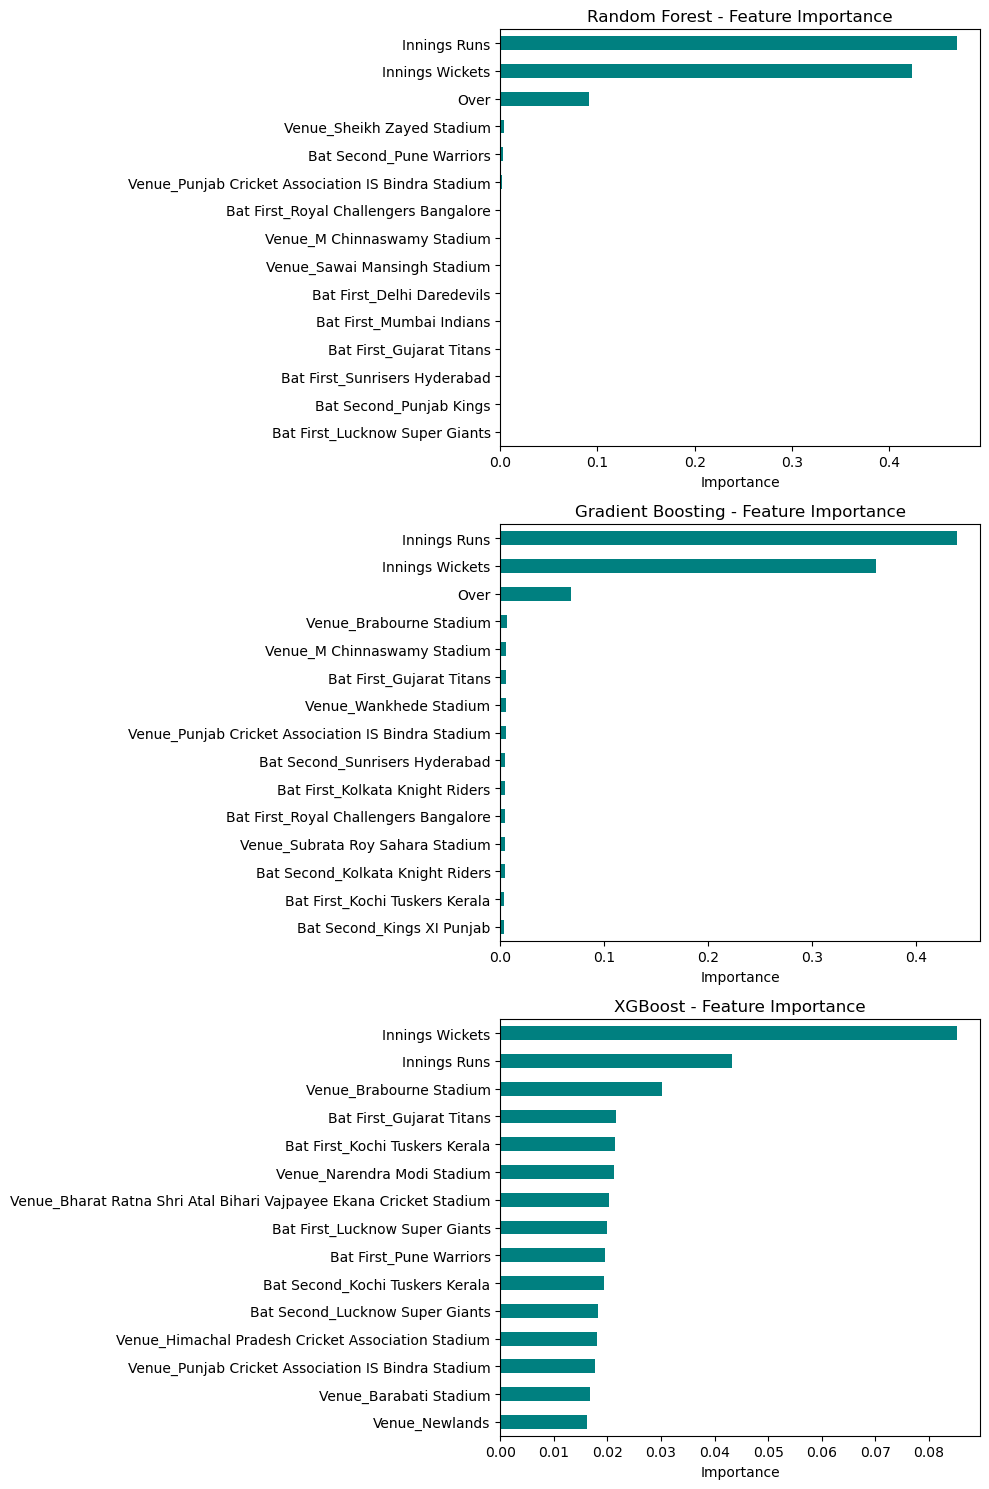

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    importance = pd.Series(
        model.named_steps["model"].feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False).head(15)

    importance.plot.barh(ax=ax, color='teal')
    ax.set_title(f"{name} - Feature Importance")
    ax.invert_yaxis()
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


### Visualization Analysis: Feature Importance
- **Marking Values:** The longest bars at the top of the chart represent the features that drove the model's decision-making process the most.
- **Correct Interpretation:** If a feature has 0 importance, the tree/forest never used it to make a split. It can be safely dropped from the dataset.
- **How to Interpret:** The X-axis represents the magnitude of the feature's contribution (e.g., Gini impurity reduction) to the final predictions.
- **Common Mistakes:** Assuming a low feature importance means the feature is globally useless. It might just be heavily correlated with a higher-ranking feature that "stole" its importance.

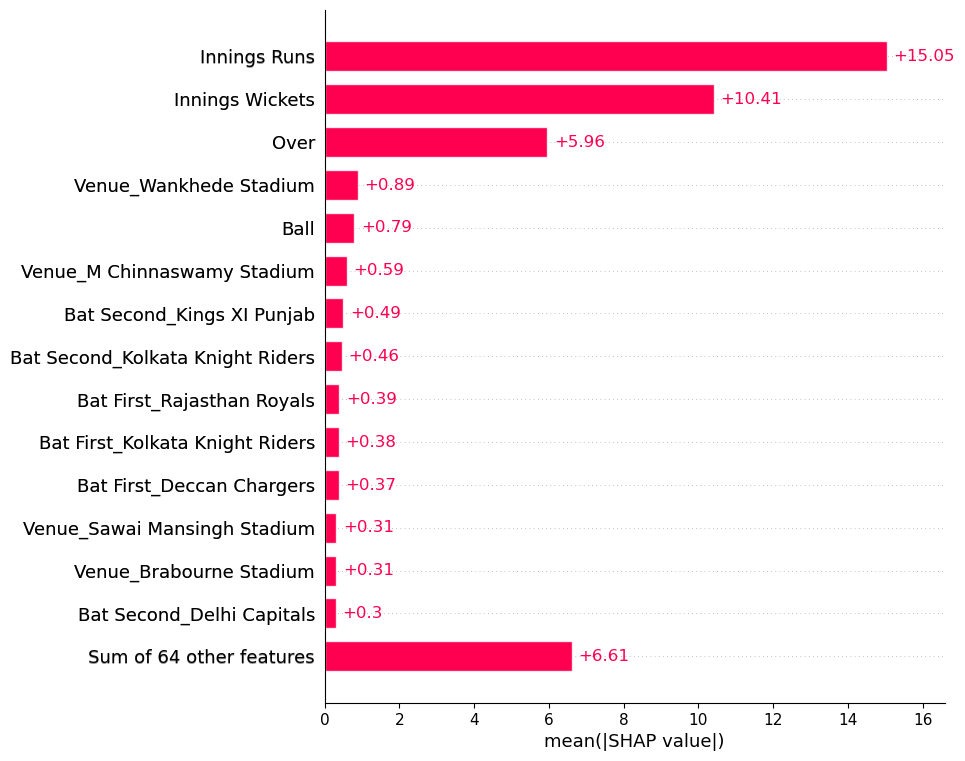

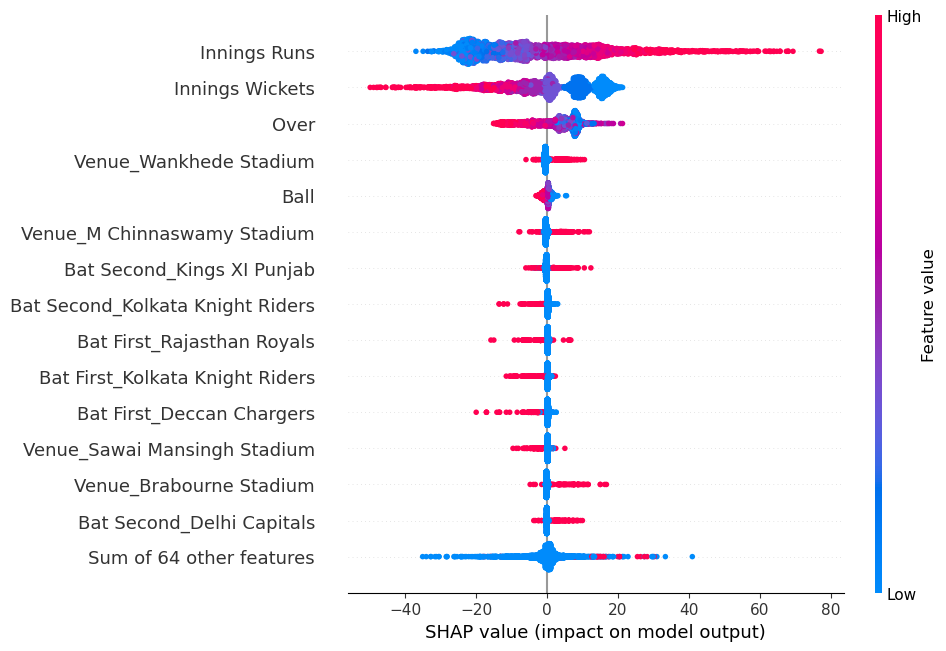

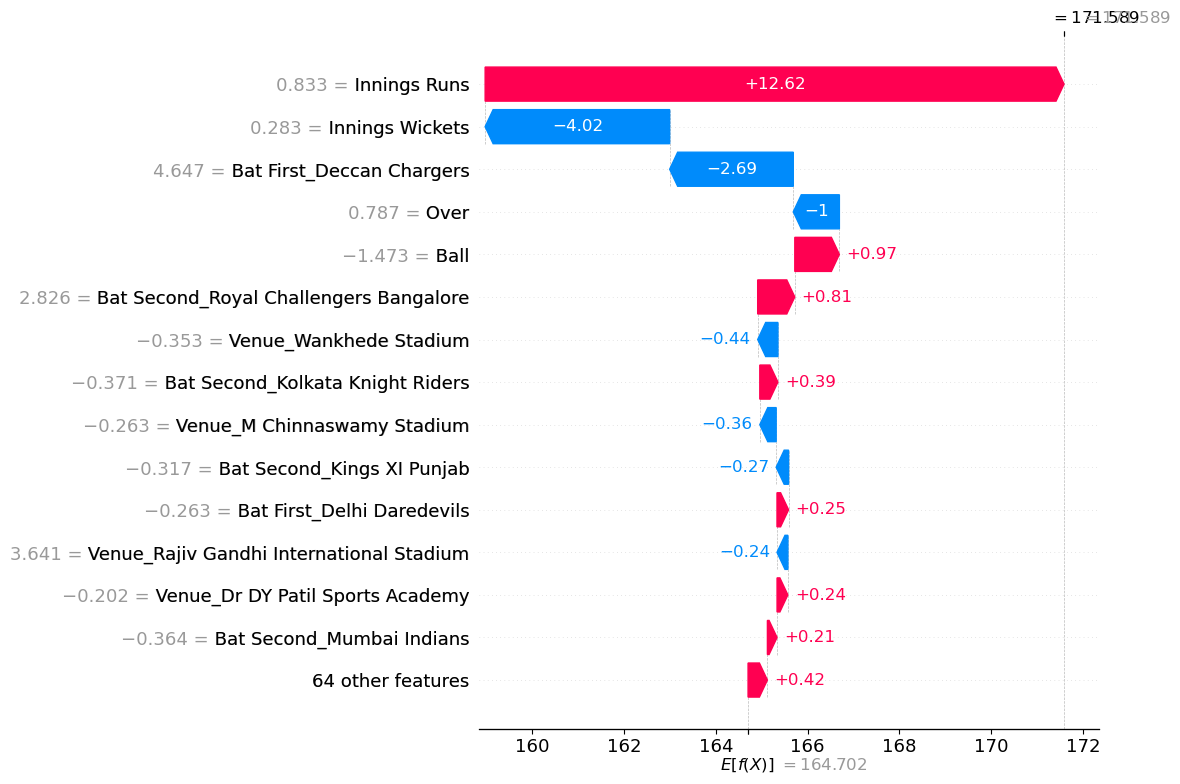

In [13]:
import shap

scaler = xgboost_model.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)

xgb = xgboost_model.named_steps["model"]
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_scaled)
shap_values.feature_names = X_test.columns.tolist()

shap.plots.bar(shap_values, max_display=15)
shap.plots.beeswarm(shap_values, max_display=15)
shap.plots.waterfall(shap_values[0], max_display=15)

shap.initjs()
shap.plots.force(shap_values[0])


### Comparison
- **Random Forest vs Gradient Boosting vs XGBoost:** Random Forest averages independent trees trained on the raw scaled features. Gradient Boosting and XGBoost instead grow each new tree on the residual runs left over from all prior trees — the model refines its score estimate step by step rather than voting once.

### Common Mistakes
- **Beginner Mistake:** Letting `learning_rate` stay at its default (0.1) while cranking `n_estimators` way up without checking CV scores — on a resampled 20k-row subset like this one, that combination can quietly overfit to noise in `Over`/`Ball` progression rather than genuine scoring patterns.

### Practical Takeaway
- **Industry Application:** Live win-probability and projected-score models in cricket broadcasts (e.g., "CSK projected to finish at 187") — the exact regression task this notebook builds, just at broadcast scale.

### Key Insight
- **Memorable lesson:** Random Forest's 100 trees each vote once, independently. XGBoost's 100 trees each look at the last tree's mistakes first — by the 100th tree, it's correcting errors the first 99 never touched. That's why boosting usually squeezes out a few extra R² points here.